<a href="https://colab.research.google.com/github/hoangson281205/ueh-ktlt-eco/blob/Gi%E1%BB%AFa-k%E1%BB%B3/Lab2(2_1_3)final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 2.1.3. Bài tập thực hành 1
Xây dựng cây quyết định và rừng cây trên dữ liệu Titanic lấy từ   
https://www.kaggle.com/code/dmilla/introduction-to-decision-trees-titanic-dataset


#### Bước 1: Import các thư viện cần thiết

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400
import graphviz

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Nhận xét**

Bảng trên thể hiện năm bản ghi đầu tiên của tập dữ liệu Titanic, bao gồm các thông tin cơ bản của hành khách như mã định danh (PassengerId), tình trạng sống sót (Survived), hạng vé (Pclass), họ tên, giới tính (Sex), tuổi (Age), số người thân đi cùng (SibSp, Parch), vé (Ticket), giá vé (Fare), số phòng (Cabin) và cảng lên tàu (Embarked).


#### Bước 2: Tiền xử lý dữ liệu

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Giữ lại các biến quan trọng cho mô hình
features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','Survived']
df = df[features]

# Xóa các hàng có giá trị thiếu
df = df.dropna()

# Chuyển đổi biến phân loại sang số
df['Sex'] = df['Sex'].map({'male':0, 'female':1})
df['Embarked'] = df['Embarked'].map({'S':0, 'C':1, 'Q':2})

# Tách X (đặc trưng) và y (nhãn)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Chia dữ liệu train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

#### Bước 3: Vẽ mô hình Tree Decision

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


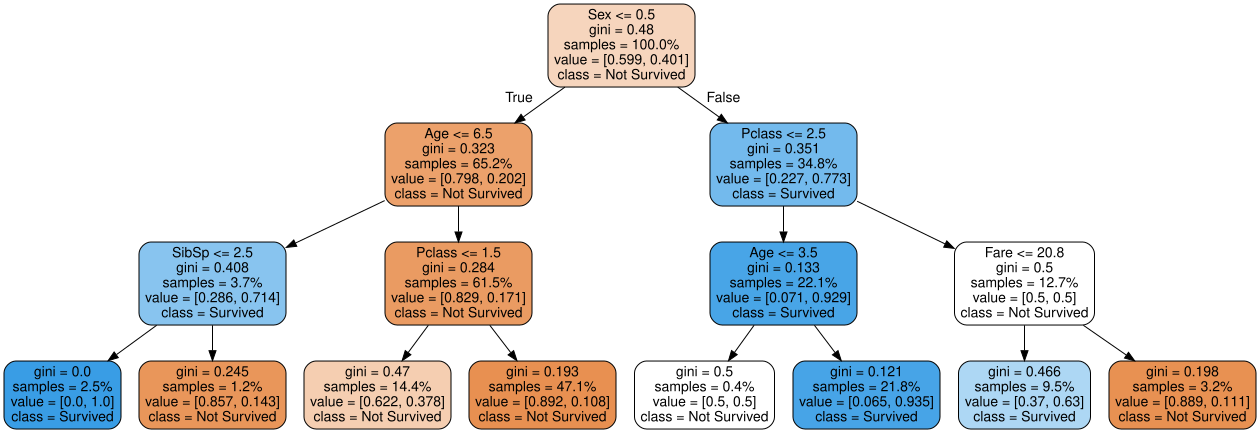

In [ ]:
!apt-get install graphviz -q
!pip install graphviz -q

from sklearn import tree
import graphviz
dot_data = tree.export_graphviz(
    dt,
    out_file=None,
    feature_names=X.columns,
    class_names=['Not Survived','Survived'],
    filled=True,
    rounded=True,
    proportion=True
)
graph = graphviz.Source(dot_data)
graph


**Nhận xét**

Cây quyết định cho thấy Pclass (hạng vé) là yếu tố phân tách đầu tiên, chứng tỏ hành khách ở hạng vé cao có xác suất sống sót lớn hơn đáng kể so với các hạng thấp. Ở nhánh trái, nhóm hành khách trẻ tuổi (tuổi ≤ 17,5) hoặc có giá vé cao thể hiện tỷ lệ sống sót vượt trội, phản ánh chính sách “ưu tiên phụ nữ và trẻ em” trong tình huống tàu đắm. Ngược lại, các nhánh màu cam cho thấy hành khách lớn tuổi, hạng vé thấp và giá vé rẻ có xác suất sống sót rất thấp, thể hiện rõ sự chênh lệch về cơ hội giữa các nhóm hành khách trên con tàu Titanic.



#### Bước 4: Tạo Classification Report

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = dt.predict(X_test)

print(" Accuracy:", accuracy_score(y_test, y_pred))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))


 Accuracy: 0.7622377622377622

 Confusion Matrix:
 [[68 15]
 [19 41]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.82      0.80        83
           1       0.73      0.68      0.71        60

    accuracy                           0.76       143
   macro avg       0.76      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143



**Nhận xét**

Kết quả cho thấy mô hình đạt độ chính xác khoảng 76,2%, thể hiện khả năng dự đoán tương đối tốt trên tập kiểm tra. Tuy nhiên, chỉ số recall của lớp “Sống sót” (0.68) thấp hơn so với lớp “Không sống sót”, cho thấy mô hình vẫn dễ bỏ sót một phần các trường hợp sống sót thực tế.


#### Bước 5: Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV

In [ ]:

from sklearn.model_selection import GridSearchCV
from sklearn import tree
from sklearn.metrics import roc_auc_score, accuracy_score

# Hiển thị đồ thị trong Colab
%matplotlib inline
plt.rcParams['figure.dpi'] = 150

print("Libraries imported.")


Libraries imported.


#### Bước 6: Thiết lập GridSearchCV cho DecisionTree (tối ưu max_depth)

In [ ]:

param_grid = {'max_depth': [1, 2, 3, 4, 5, 6, 8, 10, 12]}

dt_model = tree.DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=4,
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)


grid.fit(X_train, y_train)

print("GridSearch hoàn tất.")
print("Best params:", grid.best_params_)
print("Best CV ROC AUC (mean):", grid.best_score_)


Fitting 4 folds for each of 9 candidates, totalling 36 fits
GridSearch hoàn tất.
Best params: {'max_depth': 3}
Best CV ROC AUC (mean): 0.8562894496844025


#### Bước 7: Trích cv_results_ và vẽ biểu đồ mean ± 1 SE

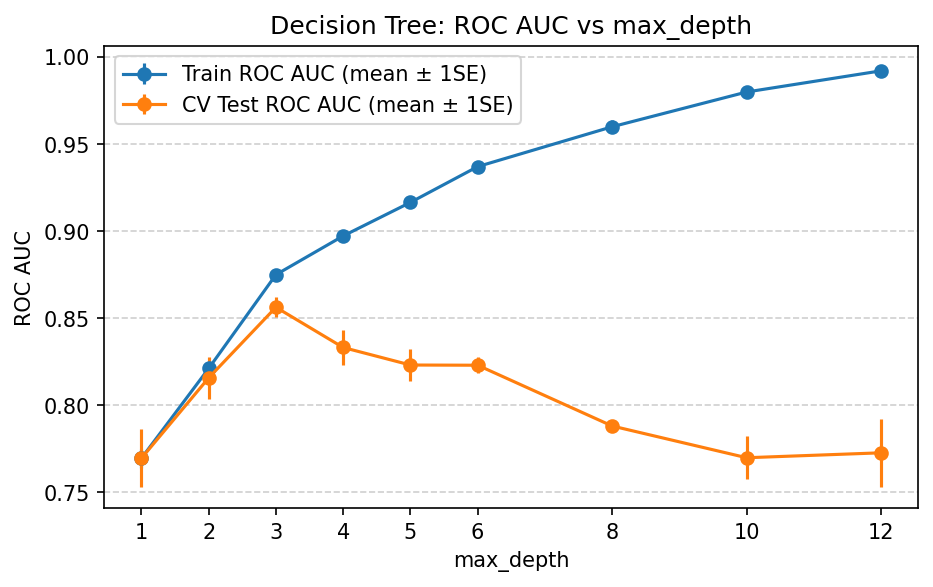

In [ ]:

cv_results_df = pd.DataFrame(grid.cv_results_)

# Chuyển param_max_depth sang int để vẽ
depths = cv_results_df['param_max_depth'].astype(int)

mean_train = cv_results_df['mean_train_score']
std_train  = cv_results_df['std_train_score']
mean_test  = cv_results_df['mean_test_score']
std_test   = cv_results_df['std_test_score']

n_splits = 4

plt.figure(figsize=(7,4))
plt.errorbar(depths, mean_train, yerr=std_train/np.sqrt(n_splits),
             label='Train ROC AUC (mean ± 1SE)', marker='o')
plt.errorbar(depths, mean_test, yerr=std_test/np.sqrt(n_splits),
             label='CV Test ROC AUC (mean ± 1SE)', marker='o')
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.title('Decision Tree: ROC AUC vs max_depth')
plt.xticks(depths)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.show()


**Nhận xét**

Đường Train ROC AUC tăng liên tục khi max_depth tăng, tiến gần đến 1 — biểu hiện của khả năng mô hình khớp tốt với dữ liệu huấn luyện (tăng độ phức tạp → tăng khả năng khớp).
Đường CV Test ROC AUC đạt đỉnh quanh max_depth ≈ 3 rồi giảm dần khi max_depth lớn hơn — đây là dấu hiệu rằng độ sâu ~3 là điểm cân bằng tốt giữa underfitting và overfitting.
Khoảng cách ngày càng lớn giữa Train và Test khi max_depth tăng cho thấy overfitting: tăng độ phức tạp vượt ngưỡng làm giảm khả năng khái quát hóa lên dữ liệu mới.


#### Bước 8: Đánh giá best_estimator_ trên X_test

In [ ]:

best_dt = grid.best_estimator_

# Dự báo probability để tính ROC AUC
y_test_proba = best_dt.predict_proba(X_test)[:, 1]
test_rocauc = roc_auc_score(y_test, y_test_proba)

# Dự đoán nhãn theo ngưỡng 0.5 để tính accuracy
y_test_pred = (y_test_proba >= 0.5).astype(int)
test_acc = accuracy_score(y_test, y_test_pred)

print("Đánh giá trên tập test:")
print(f"Test ROC AUC = {test_rocauc:.4f}")
print(f"Test Accuracy = {test_acc:.4f}")

# Lưu kết quả GridSearch (tuỳ chọn)
cv_results_df.to_csv('dt_gridsearch_results.csv', index=False)
print("Kết quả cv đã lưu thành 'dt_gridsearch_results.csv' trong workspace.")


Đánh giá trên tập test:
Test ROC AUC = 0.8335
Test Accuracy = 0.7692
Kết quả cv đã lưu thành 'dt_gridsearch_results.csv' trong workspace.


**Nhận xét**

Kết quả cho thấy mô hình đạt ROC AUC = 0.8335 và độ chính xác = 76.9%, phản ánh khả năng phân loại khá tốt giữa hai nhóm hành khách. Giá trị ROC AUC trên 0.8 cho thấy mô hình có khả năng nhận diện và phân biệt nhóm sống sót hiệu quả, đồng thời duy trì độ ổn định khi áp dụng trên dữ liệu kiểm tra.


#### Bước 9:  Import các thư viện cần thiết để xây dựng rừng cây (random forest)

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

print("Libraries imported.")


Libraries imported.


#### Bước 10: Thiết lập mô hình Random Forest và tìm tham số n_estimators tối ưu

In [ ]:

rf = RandomForestClassifier(
    criterion='gini',
    max_depth=6,
    random_state=42
)

# Tập giá trị n_estimators cần thử (10 → 100)
rf_params = {'n_estimators': list(range(10, 110, 10))}

cv_rf = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    scoring='roc_auc',
    cv=4,
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

cv_rf.fit(X_train, y_train)
print(" GridSearchCV hoàn tất.")
print("Best params:", cv_rf.best_params_)
print("Best CV ROC AUC:", cv_rf.best_score_)


Fitting 4 folds for each of 10 candidates, totalling 40 fits
 GridSearchCV hoàn tất.
Best params: {'n_estimators': 20}
Best CV ROC AUC: 0.8635694914440685


#### Bước 11: Trích kết quả cv_results_ và vẽ biểu đồ

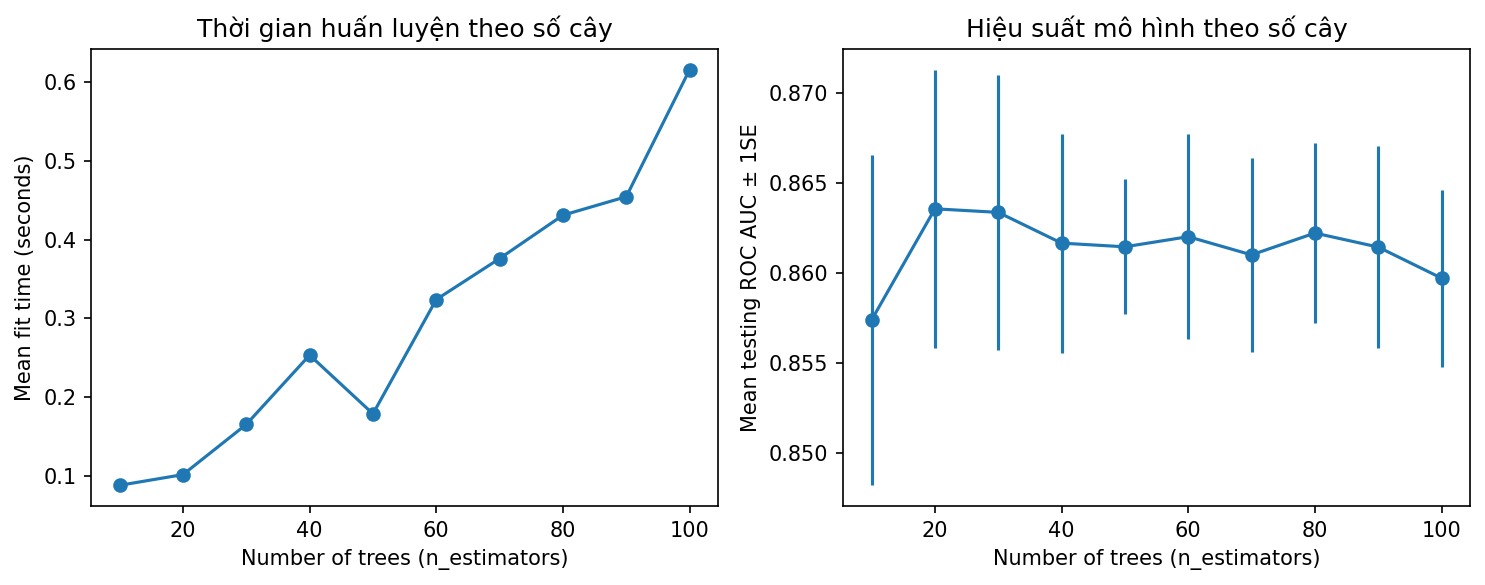

In [ ]:

cv_rf_results_df = pd.DataFrame(cv_rf.cv_results_)

fig, axs = plt.subplots(1, 2, figsize=(10,4))

# Biểu đồ thời gian huấn luyện
axs[0].plot(cv_rf_results_df['param_n_estimators'], cv_rf_results_df['mean_fit_time'], '-o')
axs[0].set_xlabel('Number of trees (n_estimators)')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[0].set_title('Thời gian huấn luyện theo số cây')

# Biểu đồ ROC AUC
axs[1].errorbar(cv_rf_results_df['param_n_estimators'],
                cv_rf_results_df['mean_test_score'],
                yerr=cv_rf_results_df['std_test_score']/np.sqrt(4),
                fmt='-o')
axs[1].set_xlabel('Number of trees (n_estimators)')
axs[1].set_ylabel('Mean testing ROC AUC ± 1SE')
axs[1].set_title('Hiệu suất mô hình theo số cây')

plt.tight_layout()
plt.show()


**Nhận xét**

Biểu đồ “Thời gian huấn luyện theo số cây”
Thời gian huấn luyện có xu hướng tăng nhanh khi số lượng cây (n_estimators) tăng, đặc biệt rõ rệt trong giai đoạn từ 20 đến 70 cây, cho thấy mô hình đòi hỏi tài nguyên tính toán và thời gian xử lý lớn hơn khi mở rộng quy mô huấn luyện
Sau ngưỡng khoảng 70 cây, thời gian huấn luyện giảm nhẹ và dao động, hiện tượng này có thể bắt nguồn từ sự thay đổi trong quá trình tối ưu nội bộ của thuật toán hoặc sai số đo lường, chứ không phản ánh sự cải thiện thực sự về tốc độ

Biểu đồ “Hiệu suất mô hình theo số cây”
Hiệu suất mô hình đo bằng chỉ tiêu ROC AUC đạt mức tương đối cao và ổn định trong khoảng từ 20 đến 80 cây, dao động quanh ngưỡng 0,86 đến 0,865, cho thấy việc tăng số cây sau một mức nhất định không còn mang lại cải thiện đáng kể về độ chính xác
Sai số thể hiện qua các thanh phương sai giảm dần khi số cây tăng, phản ánh mức độ ổn định cao hơn của mô hình, tuy nhiên lợi ích này không tương xứng với chi phí huấn luyện tăng thêm


#### Bước 12: Xem tham số tối ưu và biểu đồ Feature Importance

Best parameters: {'n_estimators': 20}


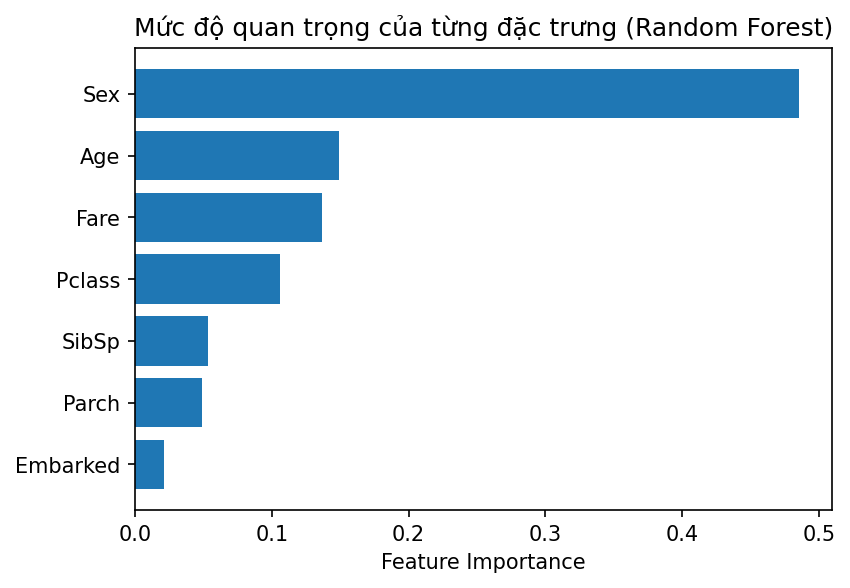

In [ ]:

print("Best parameters:", cv_rf.best_params_)

feat_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cv_rf.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(6,4))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Mức độ quan trọng của từng đặc trưng (Random Forest)')
plt.show()


**Nhận xét**

Biểu đồ cho thấy biến Sex có mức độ quan trọng cao nhất, vượt trội so với các biến còn lại, cho thấy giới tính là yếu tố quyết định mạnh nhất đến khả năng sống sót. Hai biến Age và Fare cũng có ảnh hưởng đáng kể, phản ánh mối liên hệ giữa độ tuổi, mức giá vé với khả năng sống sót. Các biến như Pclass, SibSp, Parch và Embarked đóng vai trò thứ yếu, cho thấy tác động hạn chế trong mô hình dự đoán.


#### Bước 13: Đánh giá mô hình tốt nhất trên test set

In [ ]:

best_rf = cv_rf.best_estimator_

y_test_proba = best_rf.predict_proba(X_test)[:,1]
y_test_pred = best_rf.predict(X_test)

rocauc = roc_auc_score(y_test, y_test_proba)
acc = accuracy_score(y_test, y_test_pred)

print(f" Test ROC AUC: {rocauc:.4f}")
print(f" Test Accuracy: {acc:.4f}")


 Test ROC AUC: 0.8522
 Test Accuracy: 0.7692


**Nhận xét**

Kết quả cho thấy mô hình Random Forest đạt ROC AUC = 0,8522 và Accuracy = 0,7692, phản ánh khả năng phân loại tốt với độ chính xác khá cao.
Giá trị ROC AUC trên 0,85 chứng tỏ mô hình phân biệt hiệu quả giữa hai nhóm mục tiêu, đồng thời hạn chế được tình trạng dự đoán sai lệch.
Mức độ chính xác gần 77% cho thấy mô hình hoạt động ổn định trên tập kiểm định, phù hợp cho bài toán phân loại nhị phân có mức độ nhiễu dữ liệu vừa phải.

